# Cleaning of student performance data

### Initial Data audit

In [1]:
#import libraries need

import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
# load the csv file
df = pd.read_csv('../data/student_performance.csv')  # na_values=['None', 'NULL', ''] preventing automatic conversion of 'None', 'NULL', and empty strings to NaN #keep_default_na=False  # preventing automatic conversion of 'None', 'NULL', and empty strings to NaN

In [3]:
#inspect shape
# number of entries
df.shape

(500, 11)

In [4]:
#review types
df.info()   #gives an overview of columns, datatypes, 

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 43.1 KB


In [5]:
#preview rows
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


#### High cardinal cleaning


In [6]:
# remove student_id  because it does not contain predictive patterns
df = df.drop(df.columns[0], axis=1) # preferable when columns are not responding to df.drop(columns=[''], axis=1, inplace=True)

In [7]:
# Preview of data after removing the student_id
df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,Female,19,10,90.5,High School,Yes,No,73,49,No
3,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,Female,15,25,73.0,High School,No,Yes,67,77,Yes


### Missing value scanning

In [8]:
df.isna().sum()

gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64

In [9]:
# missing files were found in parent_education column
df["parent_education"].unique()


<StringArray>
['Bachelor', 'High School', 'Master', nan, 'PhD']
Length: 5, dtype: str

In [10]:
#Being a categorical columns(age, parent education internet access) we used mode to fill the missing value
# if it was  continuous coulmns (age, studyhoursperweek, attendancerate) we use median to fill the missing value
# if it was a performance metics (previous score, final score ) we use mean to fill the missing value
df["parent_education"]=df["parent_education"].fillna(df["parent_education"].mode()[0])

In [11]:
df.isna().sum()


gender                  0
age                     0
study_hours_per_week    0
attendance_rate         0
parent_education        0
internet_access         0
extracurricular         0
previous_score          0
final_score             0
passed                  0
dtype: int64

In [12]:
df["parent_education"].unique()

<StringArray>
['Bachelor', 'High School', 'Master', 'PhD']
Length: 4, dtype: str

In [13]:
df.head(10)

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,Female,19,10,90.5,High School,Yes,No,73,49,No
3,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,Female,15,25,73.0,High School,No,Yes,67,77,Yes
5,Female,19,8,85.2,High School,Yes,No,40,37,No
6,Male,18,10,72.7,Master,Yes,No,75,42,No
7,Female,15,21,81.7,Master,Yes,Yes,89,70,Yes
8,Female,19,9,84.2,High School,Yes,Yes,70,49,No
9,Female,15,8,95.7,Master,No,Yes,93,56,Yes


### Outlier Handling

#### Handling outliers in Study hours per week

In [14]:
df['study_hours_per_week'].unique()

array([25,  2, 10, 26,  8, 21,  9, 18,  4, 13, 30, 19, 29, 20, 15,  7, 14,
       12, 28,  3, 11, 22, 23, 27, 24,  6,  5, 16, 17])

In [15]:
## TRIMMING METHOD
# Calculate Quartiles and IQR
Q1 = np.quantile(df["study_hours_per_week"],0.25)
Q3 = np.quantile(df['study_hours_per_week'],0.75)
IQR = Q3 - Q1
print(IQR)

# define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)


#filter out the outliers
#df_cleaned = df[(df['study_hours_per_week'] >= lower_bound) & (df['study_hours_per_week'] <= upper_bound)]

15.0
-14.5
45.5


In [16]:
# identify outliers in the data
outliers = [x for x in df['study_hours_per_week'] if x<lower_bound  or x>upper_bound]
type(outliers) 

list

In [17]:
outliers=pd.Series(outliers)

In [18]:
outliers.sort_values()
print(outliers)

Series([], dtype: object)


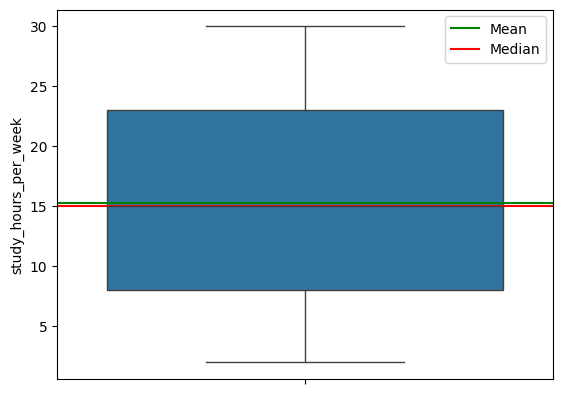

In [19]:


#lets plot a boxplot to visualize outliers
sns.boxplot(y=df['study_hours_per_week'])
mean_study_hours_per_week=df['study_hours_per_week'].mean()
median_study_hours_per_week=df['study_hours_per_week'].median()
plt.axhline(mean_study_hours_per_week,color="green", label="Mean")
plt.axhline(median_study_hours_per_week,color="red", label="Median")
plt.legend()
plt.show()

In [55]:
# The capping method
 
# cap values outside the boundaries 
df['study_hours_per_week'] = np.where((df['study_hours_per_week']<lower_bound)|(df['study_hours_per_week']>upper_bound),
                                       df["study_hours_per_week"].median(),
                                       df["study_hours_per_week"])

Histogram

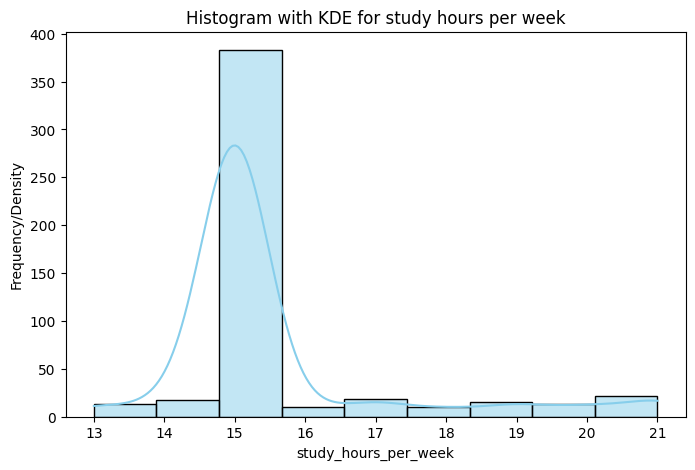

In [84]:
plt.figure(figsize=(8,5))

#Historam with KDE
sns.histplot(df['study_hours_per_week'], bins=9, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram with KDE for study hours per week')
plt.xlabel('study_hours_per_week')
plt.ylabel('Frequency/Density')
plt.show()

#### Handling Outliers in Age

In [22]:
df['age'].unique()

array([15, 19, 16, 18, 17])

In [23]:
#Finding Q1 and Q3
Q1 = np.percentile(df['age'],25)
Q3 = np.percentile(df['age'],75)

IQR = Q3-Q1
print(IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)



2.0
13.0
21.0


In [24]:
outliers = [x for x in df['age'] if x < lower_bound or x > upper_bound]
type(outliers)

list

In [25]:
outliers=pd.Series(outliers)

In [26]:
outliers.sort_values()


Series([], dtype: object)

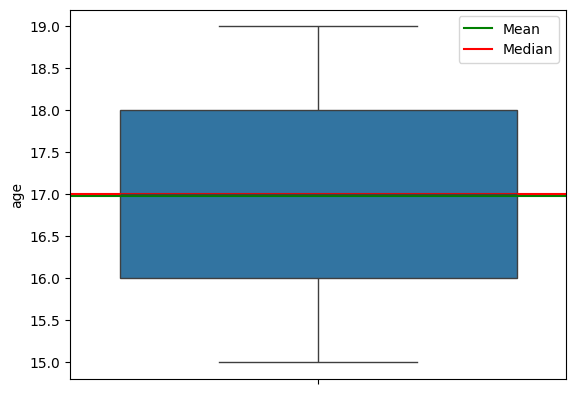

In [27]:
sns.boxplot(y=df['age'])
mean_age=df['age'].mean()
median_age=df['age'].median()
plt.axhline(mean_age,color="green", label="Mean")
plt.axhline(median_age,color="red", label="Median")
plt.legend()
plt.show()

In [86]:
# The capping method
 
# cap values outside the boundaries 
df['age'] = np.where((df["age"]<lower_bound)|(df["age"]>upper_bound),
            df["age"].median(),
            df["age"])

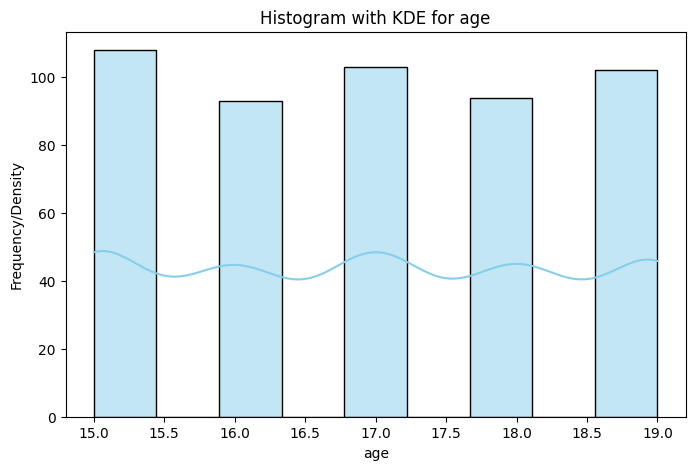

In [87]:
plt.figure(figsize=(8,5))

#Historam with KDE
sns.histplot(df['age'], bins=9, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram with KDE for age')
plt.xlabel('age')
plt.ylabel('Frequency/Density')
plt.show()

In [68]:
df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15.0,15.0,63.8,2,1,1,41,67,1
1,0,15.0,15.0,54.7,2,1,1,83,28,0
2,0,19.0,15.0,90.5,1,1,0,73,49,0
3,1,16.0,15.0,66.8,1,0,1,75,70,1
4,0,15.0,15.0,73.0,1,0,1,67,77,1


### Binary mapping 

In [31]:
#convert gender into (male/female) into 1 and 0
df['gender'] = df['gender'].map({'Male': 1, 'Female':0})

#convert internet access(yes/no) into 1 and 0
df['internet_access'] = df['internet_access'].map({'Yes': 1, 'No': 0})

#convert extracurricular (yes/no) into 1 and 0
df['extracurricular'] = df['extracurricular'].map({'Yes': 1, 'No': 0})

#convert passed (yes/no) into 1 and 0
df['passed'] = df['passed'].map({'Yes': 1, 'No': 0})

In [32]:
df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15.0,25.0,63.8,Bachelor,1,1,41,67,1
1,0,15.0,2.0,54.7,Bachelor,1,1,83,28,0
2,0,19.0,10.0,90.5,High School,1,0,73,49,0
3,1,16.0,26.0,66.8,High School,0,1,75,70,1
4,0,15.0,25.0,73.0,High School,0,1,67,77,1


###  Ordinal encoding

In [33]:
df['parent_education'].unique()

<StringArray>
['Bachelor', 'High School', 'Master', 'PhD']
Length: 4, dtype: str

In [34]:
education_mapping = {
    'Bachelor' : 2,
    'High School': 1,
    'Master': 3,
    'PhD': 4,
}
df['parent_education'] = df['parent_education'].map(education_mapping)

In [35]:
df.dtypes

gender                    int64
age                     float64
study_hours_per_week    float64
attendance_rate         float64
parent_education          int64
internet_access           int64
extracurricular           int64
previous_score            int64
final_score               int64
passed                    int64
dtype: object

In [36]:
df.head(10)
df.to_csv("../data/binary_student_perfomance.csv", index=False)


### Analysis by gender
- Determine the number of students? 
- How many students are males?
- How many students are females

In [37]:
# number of students in the dataset
num_students = df.shape[0]
print(f'The number of students in the dataset is: {num_students}')

The number of students in the dataset is: 500


In [38]:
# number of females and males
num_females =df[df['gender'] == 0].shape[0]
num_males = df[df['gender'] == 1].shape[0]

print(f'The number of females in the dataset is: {num_females}')
print(f'The number of males in the dataset is: {num_males}')

gender_difference = num_females - num_males
print(f"The female students outnumber the male students by: {gender_difference}.")

The number of females in the dataset is: 273
The number of males in the dataset is: 227
The female students outnumber the male students by: 46.


### Determine the mean, median, max and min age of the students

In [39]:
# determine the mean, median, max and min age of the students
mean_age = df['age'].mean()
median_age = df['age'].median()
max_age = df['age'].max()
min_age = df['age'].min()

print(f"The mean age of the students is: {mean_age:.2f}")
print(f"The median age of the students is: {median_age}")
print(f"The maximum age of the students is: {max_age}")
print(f"The minimum age of the students is: {min_age}")


The mean age of the students is: 16.98
The median age of the students is: 17.0
The maximum age of the students is: 19.0
The minimum age of the students is: 15.0


### Determine:
- The students with the highest study_hours_per_week
- The students with the lowest study_hours_per_week

In [40]:
# number of students with the highest  study_hours_per_week
max_study_hours = df['study_hours_per_week'].max()
students_with_max_study_hours = df[df['study_hours_per_week'] == max_study_hours]
num_students_with_max_study_hours = students_with_max_study_hours.shape[0]
print(f"The number of students with the highest study hours per week ({max_study_hours} hours) is: {num_students_with_max_study_hours}")

The number of students with the highest study hours per week (30.0 hours) is: 10


In [41]:
min_study_hours = df['study_hours_per_week'].min()
students_with_min_study_hours = df[df['study_hours_per_week'] == min_study_hours]
num_students_with_min_study_hours = students_with_min_study_hours.shape[0]
print(f"The number of students with the lowest study hours per week ({min_study_hours} hours) is: {num_students_with_min_study_hours}")

The number of students with the lowest study hours per week (2.0 hours) is: 22


### Determine
- Among the students who studied for long hours show how many passed and failed?
- Among the students who studied for short hours show how many passed and failed?

In [42]:
# Split students into long and short study hours groups
median_study_hours = df['study_hours_per_week'].median()
0
long_hours_students = df[df['study_hours_per_week'] >= median_study_hours]
short_hours_students =df[df['study_hours_per_week'] < median_study_hours]

# Count pass/fail for long study hours group 
long_passed = (long_hours_students['passed'] == 1).sum()
long_failed = (long_hours_students['passed'] == 0).sum()

print(f"\nStudents with >= {median_study_hours:.1f} hours/week (Long Study Hours):")
print(f"  Passed: {long_passed}")
print(f"  Failed: {long_failed}")
print(f"  Pass Rate: {(long_passed / (long_passed + long_failed) * 100):.1f}%")

# Count pass/fail for short study hours group
short_passed = (short_hours_students['passed'] == 1).sum()
short_failed = (short_hours_students['passed'] == 0).sum()

print(f"\nStudents with < {median_study_hours:.1f} hours/week (Short Study Hours):")
print(f"  Passed: {short_passed}")
print(f"  Failed: {short_failed}")
print(f"  Pass Rate: {(short_passed / (short_passed + short_failed) * 100):.1f}%")


Students with >= 15.0 hours/week (Long Study Hours):
  Passed: 236
  Failed: 15
  Pass Rate: 94.0%

Students with < 15.0 hours/week (Short Study Hours):
  Passed: 87
  Failed: 162
  Pass Rate: 34.9%


### Determine performance by Gender 

In [43]:
female_passed = df[df['passed'] == 1]['gender'] == 0
female_failed = df[df['passed'] == 0]['gender'] == 0

male_passed = df[df['passed'] == 1]['gender'] == 1
male_failed = df[df['passed'] ==  0]['gender'] ==  1


print(f"\nNumber of female students who passed: {female_passed.sum()}")
print(f"Number of female students who failed: {female_failed.sum()}")
print(f"Number of male students who passed: {male_passed.sum()}")
print(f"Number of male students who failed: {male_failed.sum()}")



Number of female students who passed: 174
Number of female students who failed: 99
Number of male students who passed: 149
Number of male students who failed: 78


### Determine
- Students who had internet access and their performance
- Students whose parents had bachelors, phd and highschool and their performance
- students who took part in extracurricular activites and their perfomance

In [44]:
# students with internet access at home and their performance
student_passed_with_internet = df[df['passed'] == 1]['internet_access'] == 1
student_failed_without_internet = df[df['passed'] == 0]['internet_access'] == 0
student_passed_without_internet = df[df['passed'] == 1]['internet_access'] == 0
student_failed_with_internet = df[df['passed'] == 0]['internet_access'] == 1

print(f"\nNumber of students with internet access at home who passed: {student_passed_with_internet.sum()}")
print(f"Number of students without internet access at home who failed: {student_failed_without_internet.sum()}")
print(f"Number of students with internet access at home who failed: {student_failed_with_internet.sum()}")
print(f"Number of students without internet access at home who passed: {student_passed_without_internet.sum()}")


Number of students with internet access at home who passed: 167
Number of students without internet access at home who failed: 90
Number of students with internet access at home who failed: 87
Number of students without internet access at home who passed: 156


In [45]:
# parental education level and student performance
#parental_none_student_passed = df[df['passed'] == 'Yes']['parent_education'] == 'None'
#parental_none_student_failed = df[df['passed'] == 'No']['parent_education'] ==  'None'
parental_Highschool_student_passed = df[df['passed'] == 1]['parent_education'] == 1
parental_Highschool_student_failed = df[df['passed'] == 0]['parent_education'] == 1
parental_bachelor_student_passed = df[df['passed'] == 1]['parent_education'] == 2
parental_bachelor_student_failed = df[df['passed'] == 0]['parent_education'] == 2
parental_master_student_passed = df[df['passed'] == 1]['parent_education'] == 3
parental_master_student_failed = df[df['passed'] == 0]['parent_education'] == 3
parental_PhD_student_passed = df[df['passed'] == 1]['parent_education'] == 4
parental_PhD_student_failed = df[df['passed'] == 0]['parent_education'] == 4

#print(f"\nNumber of students with parents having not specified education who passed: {parental_none_student_passed.sum()}")
#print(f"Number of students with parents having not specified education who failed: {parental_none_student_failed.sum()}")
print(f"Number of students with parents having high school education who passed: {parental_Highschool_student_passed.sum()}")
print(f"Number of students with parents having high school education who failed: {parental_Highschool_student_failed.sum()}")
print(f"Number of students with parents having bachelor education who passed: {parental_bachelor_student_passed.sum()}")
print(f"Number of students with parents having bachelor education who failed: {parental_bachelor_student_failed.sum()}")
print(f"Number of students with parents having master education who passed: {parental_master_student_passed.sum()}")
print(f"Number of students with parents having master education who failed: {parental_master_student_failed.sum()}")
print(f"Number of students with parents having PhD education who passed: {parental_PhD_student_passed.sum()}")
print(f"Number of students with parents having PhD education who failed: {parental_PhD_student_failed.sum()}")

Number of students with parents having high school education who passed: 67
Number of students with parents having high school education who failed: 28
Number of students with parents having bachelor education who passed: 52
Number of students with parents having bachelor education who failed: 45
Number of students with parents having master education who passed: 145
Number of students with parents having master education who failed: 72
Number of students with parents having PhD education who passed: 59
Number of students with parents having PhD education who failed: 32


In [46]:
# Extra curricular activities and student performance
student_passed_with_extracurricular = df[df['passed'] == 1]['extracurricular'] == 1
student_failed_with_extracurricular = df[df['passed'] == 0]['extracurricular'] == 1
student_passed_without_extracurricular = df[df['passed'] == 1]['extracurricular'] == 0
student_failed_without_extracurricular = df[df['passed'] == 0]['extracurricular'] == 0

print(f"\nNumber of students with extracurricular activities who passed: {student_passed_with_extracurricular.sum()}")
print(f"Number of students with extracurricular activities who failed: {student_failed_with_extracurricular.sum()}")
print(f"Number of students without extracurricular activities who passed: {student_passed_without_extracurricular.sum()}")
print(f"Number of students without extracurricular activities who failed: {student_failed_without_extracurricular.sum()}")


Number of students with extracurricular activities who passed: 163
Number of students with extracurricular activities who failed: 84
Number of students without extracurricular activities who passed: 160
Number of students without extracurricular activities who failed: 93


### Using Numpy
- Determine the average score of the previous_score and final_score.
- Determine the standard deviation of the previous_score and final_score.

In [47]:
# determine the mean score of students for previous scores using numpy
mean_previous_score = np.mean(df['previous_score'])
print(f"The mean previous score of the students is: {mean_previous_score:.2f}")

# determine the mean score of students for final scores using numpy
mean_final_score = np.mean(df['final_score'])
print(f"The mean final score of the students is: {mean_final_score:.2f}")

# determine the standard deviation of students for previous scores using numpy
std_previous_score = np.std(df['previous_score'])
print(f"The standard deviation of previous scores of the students is: {std_previous_score:.2f}")

# determine the standard deviation of students for final scores using numpy
std_final_score = np.std(df['final_score'])
print(f"The standard deviation of final scores of the students is: {std_final_score:.2f}")

# determine the max score of students for previous scores using numpy
max_previous_score = np.max(df['previous_score'])
print(f"The max previous score of the students is: {max_previous_score:.2f}")

# determine the max score of students for final scores using numpy
max_final_score = np.max(df['final_score'])
print(f"The max final score of the students is: {max_final_score:.2f}")

# determine the min score of students for previous scores using numpy
min_previous_score = np.min(df['previous_score'])
print(f"The min previous score of the students is: {min_previous_score:.2f}")

# determine the min score of students for final scores using numpy
min_final_score = np.min(df['final_score'])
print(f"The min final score of the students is: {min_final_score:.2f}")

The mean previous score of the students is: 62.99
The mean final score of the students is: 55.98
The standard deviation of previous scores of the students is: 18.92
The standard deviation of final scores of the students is: 15.36
The max previous score of the students is: 95.00
The max final score of the students is: 95.00
The min previous score of the students is: 30.00
The min final score of the students is: 20.00


## Using Pandas

In [48]:
# determine the mean score of students for previous scores 
mean_students_previous_score = df['previous_score'].mean()
print(f"The mean previous score of the students is: {mean_students_previous_score:.2f}")

# determine the mean score of students for final scores
mean_students_final_score = df['final_score'].mean()
print(f"The mean final score of the students is: {mean_students_final_score:.2f}")

# determine standard deviation of students for previous scores
std_students_previous_score = df['previous_score'].std()
print(f"The standard deviation of previous scores of the students is: {std_students_previous_score:.2f}")

# determine standard deviation of students for final scores
std_students_final_score = df['final_score'].std()
print(f"The standard deviation of final scores of the students is: {std_students_final_score:.2f}")

# determine the max score of students for previous scores
max_students_previous_score = df['previous_score'].max()
print(f"The max previous score of the students is: {max_students_previous_score:.2f}")

# determine the max score of students for final scores
max_students_final_score = df['final_score'].max()
print(f"The max final score of the students is: {max_students_final_score:.2f}")

# determine the min score of students for previous scores
min_students_previous_score = df['previous_score'].min()
print(f"The min previous score of the students is: {min_students_previous_score:.2f}")

# determine the min score of students for final scores
min_students_final_score = df['final_score'].min()
print(f"The min final score of the students is: {min_students_final_score:.2f}")

The mean previous score of the students is: 62.99
The mean final score of the students is: 55.98
The standard deviation of previous scores of the students is: 18.94
The standard deviation of final scores of the students is: 15.37
The max previous score of the students is: 95.00
The max final score of the students is: 95.00
The min previous score of the students is: 30.00
The min final score of the students is: 20.00


### Determine:
- How many student that scored below average, average & above average in previous and final score?


#### Previous test

In [49]:
# number of students with previous score above 80 (above average)
num_students_above_average_in_previous_score = df[df['previous_score'] > 80].shape[0]
print(f"The number of students with previous score above 80 is: {num_students_above_average_in_previous_score}")

# number of students with 70-79 previous score (average)
num_students_average_in_previous_score = df[(df['previous_score'] >= 70) & (df['previous_score'] < 80)].shape[0]
print(f"The number of students with previous score between 70 and 79 is: {num_students_average_in_previous_score}")

# number of students with previous score below 70 (below average)
num_students_below_average_in_previous_score = df[df['previous_score'] < 70].shape[0]
print(f"The number of students with previous score below 70 is: {num_students_below_average_in_previous_score}")


The number of students with previous score above 80 is: 121
The number of students with previous score between 70 and 79 is: 74
The number of students with previous score below 70 is: 303


#### Final score

In [50]:
# number of student with final score above 80 (above average)
num_students_above_average_in_final_score = df[df['final_score'] > 80].shape[0]
print(f"The number of students with final score above 80 is: {num_students_above_average_in_final_score}")

# number of students with 70-79 final score (average)
num_students_average_in_final_score = df[(df['final_score'] <= 70) & (df['final_score'] < 80)].shape[0]
print(f"The number of students with final score between 70 and 79 is: {num_students_average_in_final_score}")

# number of students with final score below 70 (below average)
num_students_below_average_in_final_score = df[df['final_score'] < 70].shape[0]
print(f"The number of students with final score below 70 is: {num_students_below_average_in_final_score}")

The number of students with final score above 80 is: 21
The number of students with final score between 70 and 79 is: 398
The number of students with final score below 70 is: 385


### Correlation of variables


This code snippet calculates and displays the statistical relationship between two variables in your student performance dataset: previous scores and final scores.

The first line uses pandas' `.corr()` method to compute a **correlation matrix**. This method examines the two columns you've selected—`previous_score` and `final_score`—and calculates how strongly they move together. The correlation matrix is a table showing correlation coefficients between all pairs of columns.

Correlation coefficients range from -1 to 1. A value close to 1 indicates a strong positive relationship (as previous scores increase, final scores tend to increase). A value close to -1 indicates a strong negative relationship (as one increases, the other decreases). A value near 0 suggests little to no linear relationship between the variables.

The `print()` statement displays the correlation matrix in a readable format. The resulting output will show a 2×2 matrix where the diagonal values are always 1 (each variable perfectly correlates with itself), and the off-diagonal values show the correlation between previous and final scores.

This analysis helps you understand whether a student's previous academic performance is a good predictor of their final scores. If the correlation is high (close to 1), previous performance is strongly predictive. If it's low, other factors may be more influential in determining final outcomes.

In [51]:
# correlation between previous scores and final scores
corr_matrix = df[['previous_score', 'final_score']].corr()
correlation = corr_matrix.loc['previous_score', 'final_score']

print("\nCorrelation matrix between previous scores and final scores:")
print(corr_matrix)
print(f"\nThe Pearson correlation coefficient is {correlation:.3f}, which indicates a weak positive relationship between previous and final scores.")


Correlation matrix between previous scores and final scores:
                previous_score  final_score
previous_score        1.000000     0.164958
final_score           0.164958     1.000000

The Pearson correlation coefficient is 0.165, which indicates a weak positive relationship between previous and final scores.


In [52]:
# correlation of performance with attendance
attendance_passed = df[df['passed'] == 1]['attendance_rate'].mean()
attendance_failed = df[df['passed'] == 0]['attendance_rate'].mean()
print(f"\nAverage attendance rate for passed students: {attendance_passed:.2f}%")
print(f"Average attendance rate for failed students: {attendance_failed:.2f}%")




Average attendance rate for passed students: 77.94%
Average attendance rate for failed students: 73.53%
